# 16 — Screening: finestre prosodiche sovrapposte (fase 1)

**Domanda (proposta del relatore).** Le finestre da 200 ms senza sovrapposizione possono tagliare un evento
vocale a metà. Ridurre il **passo** fra finestre, a parità di **lunghezza** (200 ms), cambia le prestazioni?

**Configurazioni** (stessa lunghezza, cambia solo il passo):

| nome | lunghezza | passo | sovrapposizione |
|---|---|---|---|
| `w200_h200` | 200 ms | 200 ms | 0 (configurazione attuale, riferimento) |
| `w200_h150` | 200 ms | 150 ms | 50 ms |
| `w200_h100` | 200 ms | 100 ms | 100 ms |

**Protocollo: identico al notebook 03 (fasi B e C)**, così il riferimento si confronta con il 26,84% già misurato:
stessi 1.000 file del train (seed 42), stessi 3 fold per parlante con i bona fide bilanciati, Model A di Pitch
Imperfect, 15 epoche, Adam lr 1e-3, batch 32, `pos_weight` sul fold di training, configurazione Praat
`standard`, semi 0, 1, 2. L'unica differenza di estrazione è il passo in `make_windows`; con passo = lunghezza
la funzione è identica a quella dei notebook 03 e 04.

**Metrica.** EER ufficiale ASVspoof (`eval_metrics.py`) sulle predizioni di tutti i fold riunite. Si calcola
anche l'EER con la funzione del notebook 03 (basata su `roc_curve`), **solo** per verificare che il riferimento
riproduca il 26,84%: quella funzione non è l'implementazione ufficiale.

**Regola di decisione, fissata prima.** Per ogni configurazione sovrapposta, bootstrap appaiato di
δ = EER(sovrapposta) − EER(riferimento), sugli stessi file e con lo stesso seme. Si conclude «migliore» solo se
l'IC 95% è interamente sotto lo zero in tutti e tre i semi. Con circa 90 bona fide gli IC saranno larghi: uno
screening negativo dice che un eventuale effetto è piccolo rispetto alla risoluzione di questo protocollo,
non che sia assente.


In [1]:
import os, sys, re, json, time, hashlib, importlib.util, urllib.request, subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, PackedSequence

try:
    import parselmouth
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth==0.4.7"], check=True)
    import parselmouth
from parselmouth.praat import call
assert (parselmouth.__version__, parselmouth.PRAAT_VERSION) == ("0.4.7", "6.1.38"), \
    f"parselmouth {parselmouth.__version__} / Praat {parselmouth.PRAAT_VERSION}: attesi 0.4.7 / 6.1.38 (notebook 03 e 04)"

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/screening_sovrapposizione"))
CACHE_DIR = OUT_DIR / "features_cache"
for d in (OUT_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- identici al notebook 03 -------------------------------------------------
SEED = 42
N_FILES = int(os.environ.get("N_FILES", 1000))
N_WORKERS = os.cpu_count() or 1
torch.set_num_threads(N_WORKERS)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0
MAX_CANDIDATES, VERY_ACCURATE, VOICING_THRESHOLD, TIME_STEP = 15, "no", 0.45, 0.0
PERIOD_FLOOR, PERIOD_CEILING = 0.8 / PITCH_CEILING, 1.25 / PITCH_FLOOR
MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR = 1.3, 1.6
HNR_TIME_STEP, HNR_SILENCE, HNR_PERIODS = 0.01, 0.1, 1.0
STANDARD = {"silence_threshold": 0.03, "octave_cost": 0.01,
            "octave_jump_cost": 0.35, "voiced_unvoiced_cost": 0.14}
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]
N_FOLDS, EPOCHS, BATCH_SIZE, LR = 3, 15, 32, 1e-3
SEEDS = [0, 1, 2]

# --- nuovo: configurazioni di finestra (lunghezza, passo) in ms --------------
FINESTRE = {"w200_h200": (200, 200), "w200_h150": (200, 150), "w200_h100": (200, 100)}
RIFERIMENTO = "w200_h200"
EER_03_RIF = {"media": 26.84, "std": 2.30}    # fase C del notebook 03: standard, 200 ms, 3 semi
N_BOOT = int(os.environ.get("N_BOOT", 1000))

print(f"parselmouth {parselmouth.__version__} | Praat {parselmouth.PRAAT_VERSION} | torch {torch.__version__} "
      f"| device {DEVICE} | core {N_WORKERS}")

parselmouth 0.4.7 | Praat 6.1.38 | torch 2.10.0+cu128 | device cuda | core 4


In [2]:
# Metrica ufficiale ASVspoof 2021, identica ai notebook precedenti.
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
assert EVAL_METRICS_SHA256.startswith("70c5d2fe8fab6654"), EVAL_METRICS_SHA256[:16]


def compute_eer(y, s):
    """EER ufficiale ASVspoof: y = 1 bona fide; punteggio alto = bona fide."""
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    return float(asv_metrics.compute_eer(s[y == 1], s[y == 0])[0])


def eer_notebook03(y, s):
    """Funzione del notebook 03, copiata identica: SOLO per il controllo di riproduzione del 26,84%."""
    fpr, tpr, _ = roc_curve(y, s, pos_label=1)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2)


def bootstrap_appaiato(y, s_rif, s_alt, n_boot=None, seed=0):
    """IC 95% di EER(s_alt) - EER(s_rif) in punti; ricampionamento separato per classe."""
    n_boot = n_boot or N_BOOT
    g = np.random.default_rng(seed)
    i_bf, i_sp = np.where(y == 1)[0], np.where(y == 0)[0]
    d = np.empty(n_boot)
    for k in range(n_boot):
        idx = np.concatenate([g.choice(i_bf, len(i_bf)), g.choice(i_sp, len(i_sp))])
        d[k] = compute_eer(y[idx], s_alt[idx]) - compute_eer(y[idx], s_rif[idx])
    d *= 100
    return float(d.mean()), tuple(np.percentile(d, [2.5, 97.5]))


assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
# --- campione e fold: identici al notebook 03 --------------------------------------------------------
def find_la_root(root):
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if "ASVspoof2019_LA_cm_protocols" in dirnames:
            return Path(dirpath)
    raise RuntimeError("Cartella con ASVspoof2019_LA_cm_protocols non trovata.")


LA_ROOT = find_la_root(INPUT_ROOT)
proto = [p for p in (LA_ROOT / "ASVspoof2019_LA_cm_protocols").iterdir() if re.search(r"cm[._]train[._]trn", p.name)]
assert len(proto) == 1, proto
train = pd.read_csv(proto[0], sep=r"\s+", header=None, dtype=str, keep_default_na=False, engine="python",
                    names=["speaker", "utt_id", "unused", "attack", "label"])
train["attack"] = train["attack"].replace("-", "bonafide")
train["path"] = [str(LA_ROOT / "ASVspoof2019_LA_train" / "flac" / f"{u}.flac") for u in train["utt_id"]]
sample = train.sample(n=min(N_FILES, len(train)), random_state=SEED).reset_index(drop=True)
sample["y"] = (sample["label"] == "bonafide").astype(np.float32)

spk = sample.groupby("speaker").agg(n_bona=("y", "sum"), n=("y", "size")).reset_index()
spk = spk.sort_values(["n_bona", "n", "speaker"], ascending=[False, False, True])
fold_bona, fold_n, spk_fold = [0] * N_FOLDS, [0] * N_FOLDS, {}
for r in spk.itertuples():
    f = min(range(N_FOLDS), key=lambda k: (fold_bona[k], fold_n[k]))
    spk_fold[r.speaker] = f; fold_bona[f] += r.n_bona; fold_n[f] += r.n
sample["fold"] = sample["speaker"].map(spk_fold)
sample[["utt_id", "speaker", "attack", "label", "fold"]].to_csv(OUT_DIR / "sample_folds.csv", index=False)
Y = sample["y"].to_numpy()
FOLDS = sample["fold"].to_numpy()
print(f"campione: {len(sample)} file | bona fide {int(Y.sum())}")
print(sample.groupby("fold").agg(file=("y", "size"), bona_fide=("y", "sum"), speaker=("speaker", "nunique")))
# Il notebook 03 stampava: fold 0 296/30/6, fold 1 368/31/7, fold 2 336/31/7 (file/bona fide/speaker)

campione: 1000 file | bona fide 92
      file  bona_fide  speaker
fold                          
0      296       30.0        6
1      368       31.0        7
2      336       31.0        7


In [4]:
# --- estrazione: funzioni del notebook 03, con il passo come unico parametro nuovo ------------------
def make_windows(duration, w, hop):
    """Con hop == w e' identica alla make_windows dei notebook 03 e 04."""
    starts = np.arange(0.0, duration, hop)
    ends = np.minimum(starts + w, duration)
    keep = (ends - starts) >= w / 2
    return starts[keep], ends[keep]


_s, _e = make_windows(1.0, 0.2, 0.2)
assert np.allclose(_s, [0, .2, .4, .6, .8]) and np.allclose(_e, [.2, .4, .6, .8, 1.0])
# Durata 0,95 s scelta lontana dal caso limite "coda esattamente = w/2", dove l'esito dipende
# dall'arrotondamento in virgola mobile di np.arange (comportamento identico al notebook 03).
_s, _e = make_windows(0.95, 0.2, 0.1)     # passo 100 ms: la finestra da 50 ms in coda viene scartata
assert np.allclose(_s, [0, .1, .2, .3, .4, .5, .6, .7, .8]) and np.allclose(_e[-1], 0.95)
_s, _e = make_windows(0.95, 0.2, 0.15)    # passo 150 ms: starts 0..0,9; coda 0,9-0,95 (50 ms) scartata
assert np.allclose(_s, [0, .15, .3, .45, .6, .75]) and np.allclose(_e[-1], 0.95)


def window_features(snd, pp, harm_t, harm_v, int_t, int_v, a, b, pitch_t, f0):
    f0w = f0[(pitch_t >= a) & (pitch_t < b)]
    f0w = f0w[f0w > 0]
    if len(f0w) == 0:
        return np.zeros(len(FEATURES))
    out = np.full(len(FEATURES), np.nan)
    out[0] = f0w.mean()
    out[1] = f0w.std() if len(f0w) >= 2 else np.nan
    try:
        out[2] = call(pp, "Get jitter (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING, MAX_PERIOD_FACTOR)
    except Exception:
        pass
    try:
        out[3] = call([snd, pp], "Get shimmer (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING,
                      MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR)
    except Exception:
        pass
    hw = harm_v[(harm_t >= a) & (harm_t < b)]; hw = hw[hw > -100]
    if len(hw):
        out[4] = hw.mean(); out[5] = hw.std() if len(hw) >= 2 else np.nan
    iw = int_v[(int_t >= a) & (int_t < b)]; iw = iw[np.isfinite(iw)]
    if len(iw):
        out[6] = iw.mean(); out[7] = iw.std() if len(iw) >= 2 else np.nan
    return out


def extract(path):
    """Analisi di Praat una sola volta per file; poi aggregazione per ciascuna configurazione di finestra."""
    snd = parselmouth.Sound(path)
    harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
    inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
    pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                 STANDARD["silence_threshold"], VOICING_THRESHOLD, STANDARD["octave_cost"],
                 STANDARD["octave_jump_cost"], STANDARD["voiced_unvoiced_cost"], PITCH_CEILING)
    pp = call([snd, pitch], "To PointProcess (cc)")
    ht, hv = np.asarray(harm.xs()), np.asarray(harm.values[0])
    it, iv = np.asarray(inten.xs()), np.asarray(inten.values[0])
    pt, f0 = np.asarray(pitch.xs()), np.asarray(pitch.selected_array["frequency"])
    out = {}
    for nome, (w_ms, h_ms) in FINESTRE.items():
        starts, ends = make_windows(snd.duration, w_ms / 1000, h_ms / 1000)
        X = np.zeros((len(starts), len(FEATURES)), dtype=np.float32)
        for i, (a, b) in enumerate(zip(starts, ends)):
            X[i] = np.nan_to_num(window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0), nan=0.0)
        if len(X) == 0:
            X = np.zeros((1, len(FEATURES)), dtype=np.float32)
        out[nome] = X
    return out


cache = CACHE_DIR / "standard.npz"
if cache.exists():
    z = np.load(cache, allow_pickle=True)
    assert (z["utt_id"] == sample["utt_id"].to_numpy()).all(), "cache di un campione diverso: cancellala"
    FEATS = {n: list(z[n]) for n in FINESTRE}
else:
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        res = list(ex.map(extract, sample["path"], chunksize=8))
    FEATS = {n: [r[n] for r in res] for n in FINESTRE}
    arrs = {}
    for n in FINESTRE:
        a = np.empty(len(FEATS[n]), dtype=object); a[:] = FEATS[n]; arrs[n] = a
    np.savez(cache, utt_id=sample["utt_id"].to_numpy(), **arrs)
    print(f"estrazione: {(time.perf_counter() - t0) / 60:.1f} min")

for n in FINESTRE:
    L = np.array([len(x) for x in FEATS[n]])
    phi = np.mean([(np.abs(x).sum(1) == 0).mean() for x in FEATS[n]])
    print(f"{n}: finestre per file min {L.min()}, mediana {np.median(L):.0f}, max {L.max()} | "
          f"frazione media di finestre mute {phi:.3f}")
# Il notebook 03 stampava per 200 ms: min 4, mediana 16, max 51

estrazione: 1.2 min
w200_h200: finestre per file min 4, mediana 16, max 51 | frazione media di finestre mute 0.310
w200_h150: finestre per file min 5, mediana 21, max 68 | frazione media di finestre mute 0.309
w200_h100: finestre per file min 7, mediana 31, max 101 | frazione media di finestre mute 0.303


In [5]:
# --- Model A e validazione incrociata: identici al notebook 03 ---------------------------------------
class ModelA(nn.Module):
    def __init__(self, n_in=len(FEATURES)):
        super().__init__()
        self.drop_in1, self.lstm1, self.bn1 = nn.Dropout(0.2), nn.LSTM(n_in, 64, batch_first=True), nn.BatchNorm1d(64)
        self.drop_in2, self.lstm2, self.bn2 = nn.Dropout(0.2), nn.LSTM(64, 32, batch_first=True), nn.BatchNorm1d(32)
        self.head = nn.Sequential(nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    @staticmethod
    def _map(packed, fn):
        return PackedSequence(fn(packed.data), packed.batch_sizes, packed.sorted_indices, packed.unsorted_indices)

    def forward(self, x, lengths):
        p = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p = self._map(p, self.drop_in1)
        p, _ = self.lstm1(p)
        p = self._map(p, self.bn1)
        p = self._map(p, self.drop_in2)
        _, (h, _) = self.lstm2(p)
        return self.head(self.bn2(h[-1])).squeeze(-1)


def minmax_fit(seqs):
    allw = np.concatenate(seqs, axis=0)
    lo, hi = allw.min(0), allw.max(0)
    return lo, np.where(hi - lo > 0, hi - lo, 1.0)


def make_batch(seqs, idx, lo, rng_):
    X = [(seqs[i] - lo) / rng_ for i in idx]
    L = torch.tensor([len(x) for x in X])
    B = torch.zeros(len(X), int(L.max()), X[0].shape[1])
    for k, x in enumerate(X):
        B[k, :len(x)] = torch.from_numpy(x.astype(np.float32))
    return B, L


def predict(model, seqs, idx, lo, rng_):
    model.eval(); out = []
    with torch.no_grad():
        for k in range(0, len(idx), 256):
            B, L = make_batch(seqs, idx[k:k + 256], lo, rng_)
            out.append(model(B.to(DEVICE), L).cpu().numpy())
    return np.concatenate(out)


def train_fold(seqs, y, tr_idx, va_idx, seed, epochs):
    torch.manual_seed(seed); np.random.seed(seed)
    lo, rng_ = minmax_fit([seqs[i] for i in tr_idx])
    model = ModelA().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    pos_w = (y[tr_idx] == 0).sum() / max((y[tr_idx] == 1).sum(), 1)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, dtype=torch.float32, device=DEVICE))
    g = np.random.default_rng(seed)
    for ep in range(epochs):
        model.train()
        perm = g.permutation(tr_idx)
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            B, L = make_batch(seqs, b, lo, rng_)
            loss = loss_fn(model(B.to(DEVICE), L), torch.from_numpy(y[b]).to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
    return predict(model, seqs, va_idx, lo, rng_)


def cross_validate_scores(seqs, seed):
    """Predizioni di validazione di tutti i fold, riunite nell'ordine del campione."""
    scores = np.zeros(len(Y))
    for f in range(N_FOLDS):
        tr, va = np.where(FOLDS != f)[0], np.where(FOLDS == f)[0]
        scores[va] = train_fold(seqs, Y, tr, va, seed, EPOCHS)
    return scores

In [6]:
# --- addestramento: 3 configurazioni x 3 semi, punteggi salvati e ripresi ---------------------------
SC = {}
righe = []
t0 = time.perf_counter()
for n in FINESTRE:
    for sd in SEEDS:
        f = OUT_DIR / f"punteggi_{n}_s{sd}.npy"
        SC[(n, sd)] = np.load(f) if f.exists() else cross_validate_scores(FEATS[n], sd)
        np.save(f, SC[(n, sd)])
        per_fold = [100 * compute_eer(Y[FOLDS == k], SC[(n, sd)][FOLDS == k]) for k in range(N_FOLDS)]
        righe.append({"configurazione": n, "seme": sd,
                      "eer_ufficiale_%": 100 * compute_eer(Y, SC[(n, sd)]),
                      "eer_funzione_03_%": 100 * eer_notebook03(Y, SC[(n, sd)]),
                      "eer_fold_media_%": float(np.mean(per_fold)), "eer_fold_std_%": float(np.std(per_fold))})
    print(f"{n}: {(time.perf_counter() - t0) / 60:.1f} min", flush=True)
RES = pd.DataFrame(righe)
RES.to_csv(OUT_DIR / "risultati_per_seme.csv", index=False)
RIEP = RES.groupby("configurazione")[["eer_ufficiale_%", "eer_funzione_03_%"]].agg(["mean", "std"]).round(2)
RIEP.to_csv(OUT_DIR / "risultati_riepilogo.csv")
print("=== EER pooled sui 3 fold (%), 3 semi ===")
display(RES.round(2))
display(RIEP)

# --- controllo di riproduzione del notebook 03 (non bloccante) --------------------------------------
rif = RES[RES["configurazione"] == RIFERIMENTO]["eer_funzione_03_%"]
scarto = abs(rif.mean() - EER_03_RIF["media"])
RIPRODOTTO = bool(scarto < 0.5)
print(f"\nriferimento {RIFERIMENTO}, funzione del notebook 03: {rif.mean():.2f} +/- {rif.std():.2f} "
      f"contro {EER_03_RIF['media']:.2f} +/- {EER_03_RIF['std']:.2f} del notebook 03 -> "
      + ("RIPRODOTTO" if RIPRODOTTO else
         f"NON riprodotto (scarto {scarto:.2f} punti): l'addestramento LSTM su GPU non e' deterministico "
         "oppure il campione e' diverso. Controlla i fold stampati sopra prima di interpretare i confronti."))

w200_h200: 0.4 min
w200_h150: 0.8 min
w200_h100: 1.2 min
=== EER pooled sui 3 fold (%), 3 semi ===


,configurazione,seme,eer_ufficiale_%,eer_funzione_03_%,eer_fold_media_%,eer_fold_std_%
0,w200_h200,0,28.17,28.17,23.80,4.11
1,w200_h200,1,23.91,24.18,21.71,6.15
2,w200_h200,2,28.17,28.17,21.75,1.72
3,w200_h150,0,26.91,26.91,21.84,4.22
4,w200_h150,1,23.09,23.09,22.98,0.78
5,w200_h150,2,25.00,25.33,23.15,5.55
6,w200_h100,0,30.42,30.36,29.39,2.07
7,w200_h100,1,34.52,34.52,25.28,6.04
8,w200_h100,2,33.64,33.64,28.01,2.52


eer_ufficiale_%       eer_funzione_03_%      
                          mean   std              mean   std
configurazione                                              
w200_h100                32.86  2.16             32.84  2.19
w200_h150                25.00  1.91             25.11  1.92
w200_h200                26.75  2.46             26.84  2.30


riferimento w200_h200, funzione del notebook 03: 26.84 +/- 2.30 contro 26.84 +/- 2.30 del notebook 03 -> RIPRODOTTO


=== delta = EER(configurazione) - EER(w200_h200), stessi file e stesso seme ===
    delta < 0: la sovrapposizione migliora. Regola: IC 95% sotto lo zero in TUTTI i semi.


,configurazione,seme,delta_%,delta_boot,ic_lo,ic_hi
0,w200_h150,0,-1.26,-0.59,-5.47,5.03
1,w200_h150,1,-0.82,-0.04,-3.23,3.29
2,w200_h150,2,-3.17,-3.46,-9.68,2.24
3,w200_h100,0,2.24,3.37,-3.17,10.83
4,w200_h100,1,10.61,10.24,4.32,16.08
5,w200_h100,2,5.47,5.33,-0.17,11.12


,delta_medio_%,delta_min_%,delta_max_%,esito
configurazione,,,,
w200_h100,6.11,2.24,10.61,non conclusivo
w200_h150,-1.75,-3.17,-0.82,non conclusivo


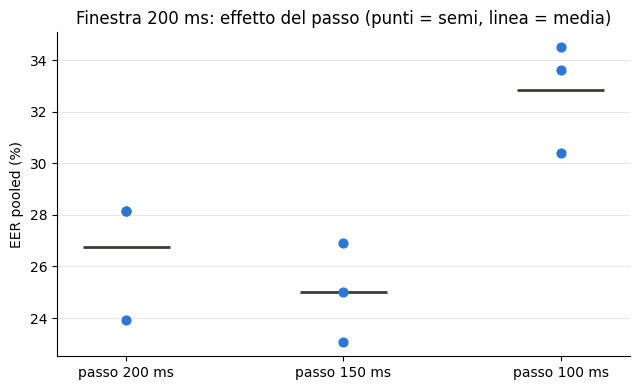

Output: ['contrasti.csv', 'decisione.csv', 'eval_metrics.py', 'fig_screening.png', 'punteggi_w200_h100_s0.npy', 'punteggi_w200_h100_s1.npy', 'punteggi_w200_h100_s2.npy', 'punteggi_w200_h150_s0.npy', 'punteggi_w200_h150_s1.npy', 'punteggi_w200_h150_s2.npy', 'punteggi_w200_h200_s0.npy', 'punteggi_w200_h200_s1.npy', 'punteggi_w200_h200_s2.npy', 'riepilogo.json', 'risultati_per_seme.csv', 'risultati_riepilogo.csv', 'sample_folds.csv']


In [7]:
# --- confronto appaiato con il riferimento, per seme ------------------------------------------------
contr = []
for n in FINESTRE:
    if n == RIFERIMENTO:
        continue
    for sd in SEEDS:
        d, (lo, hi) = bootstrap_appaiato(Y, SC[(RIFERIMENTO, sd)], SC[(n, sd)], seed=sd)
        contr.append({"configurazione": n, "seme": sd,
                      "delta_%": 100 * (compute_eer(Y, SC[(n, sd)]) - compute_eer(Y, SC[(RIFERIMENTO, sd)])),
                      "delta_boot": d, "ic_lo": lo, "ic_hi": hi})
CONTR = pd.DataFrame(contr)


def esito(g):
    if (g["ic_hi"] < 0).all():
        return "sovrapposizione migliore"
    if (g["ic_lo"] > 0).all():
        return "sovrapposizione peggiore"
    return "non conclusivo"


DECIS = pd.DataFrame([{"configurazione": n, "delta_medio_%": g["delta_%"].mean(),
                       "delta_min_%": g["delta_%"].min(), "delta_max_%": g["delta_%"].max(), "esito": esito(g)}
                      for n, g in CONTR.groupby("configurazione")]).set_index("configurazione")
CONTR.to_csv(OUT_DIR / "contrasti.csv", index=False); DECIS.to_csv(OUT_DIR / "decisione.csv")
print(f"=== delta = EER(configurazione) - EER({RIFERIMENTO}), stessi file e stesso seme ===")
print("    delta < 0: la sovrapposizione migliora. Regola: IC 95% sotto lo zero in TUTTI i semi.")
display(CONTR.round(2)); display(DECIS.round(2))

# --- figura: EER per configurazione e seme ----------------------------------------------------------
BLU = "#2a78d6"
fig, ax = plt.subplots(figsize=(6.5, 4))
nomi = list(FINESTRE)
for i, n in enumerate(nomi):
    v = RES[RES["configurazione"] == n]["eer_ufficiale_%"].to_numpy()
    ax.scatter(np.full(len(v), i), v, color=BLU, s=40, zorder=3)
    ax.hlines(v.mean(), i - 0.2, i + 0.2, color="#3d3d3a", lw=2, zorder=2)
ax.set_xticks(range(len(nomi)))
ax.set_xticklabels([f"passo {FINESTRE[n][1]} ms" for n in nomi])
ax.set_ylabel("EER pooled (%)")
ax.set_title("Finestra 200 ms: effetto del passo (punti = semi, linea = media)")
ax.grid(axis="y", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_screening.png", dpi=150); plt.show()

riepilogo = {
    "protocollo": "notebook 03: 1.000 file train (seed 42), 3 fold per speaker, Model A, 15 epoche, standard",
    "configurazioni": {n: {"lunghezza_ms": w, "passo_ms": h} for n, (w, h) in FINESTRE.items()},
    "semi": SEEDS, "n_boot": N_BOOT,
    "riproduzione_notebook03": {"riprodotto": RIPRODOTTO, "atteso": EER_03_RIF,
                                "ottenuto": {"media": float(rif.mean()), "std": float(rif.std())}},
    "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256},
    "decisione": DECIS.reset_index().to_dict("records"),
    "limiti": ["campione di 1.000 file con circa 90 bona fide: IC larghi, bassa potenza",
               "Model A del notebook 03 come strumento di misura, non il ramo P finale",
               "un solo dominio (train 2019 in validazione incrociata)",
               "il notebook 03 usava una EER non ufficiale (roc_curve): qui si riporta quella ufficiale"]}
(OUT_DIR / "riepilogo.json").write_text(json.dumps(riepilogo, indent=2, default=float))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))